# Intelligent Skin Cancer Diagnosis — Phase 0: Environment & Dataset Setup
**8-class dermoscopy classification | Local GPU (RTX 2000 Ada) | PyTorch**

Datasets:
- **HAM10000** — 10,015 images, 7 classes, ISIC metadata CSV
- **ISIC 9-class** — folder-structured Train/Test split, 9 classes ('seborrheic keratosis' merged into 'pigmented benign keratosis')

Goal: merge both datasets into a single `metadata.csv`, verify integrity, create project structure.

In [1]:
# ── 1. Imports ──────────────────────────────────────────────────────────────
import os, sys, random, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torchvision

print(f"Python      : {sys.version.split()[0]}")
print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")

# GPU check
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    gpu = torch.cuda.get_device_properties(0)
    print(f"\nGPU  : {gpu.name}")
    print(f"VRAM : {gpu.total_memory / 1024**3:.1f} GB")
    print(f"CUDA : {torch.version.cuda}")
else:
    DEVICE = torch.device('cpu')
    print("\nNo GPU found — running on CPU")

print(f"\nDevice: {DEVICE}")

Python      : 3.11.0
PyTorch     : 2.5.1+cu121
Torchvision : 0.20.1+cu121
NumPy       : 2.4.6
Pandas      : 3.0.3

GPU  : NVIDIA RTX 2000 Ada Generation
VRAM : 16.0 GB
CUDA : 12.1

Device: cuda


In [2]:
# ── 2. Reproducibility — fix all seeds ──────────────────────────────────────
SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False  # True = faster but non-deterministic

print(f"All seeds fixed to {SEED}")

All seeds fixed to 42


In [3]:
# ── 3. Logging setup ─────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)s  %(message)s',
    datefmt='%H:%M:%S'
)
log = logging.getLogger('skin_cancer')
log.info("Logger ready")

12:12:30  INFO  Logger ready


In [4]:
# ── 4. Path configuration ────────────────────────────────────────────────────
BASE_DIR  = Path(r'c:\graduation project')

# Raw dataset roots
HAM_DIR    = BASE_DIR / 'HAM1000'
ISIC_DIR   = BASE_DIR / 'ISIC' / 'Skin cancer ISIC The International Skin Imaging Collaboration'

HAM_IMG1   = HAM_DIR / 'HAM10000_images_part_1'
HAM_IMG2   = HAM_DIR / 'HAM10000_images_part_2'
HAM_META   = HAM_DIR / 'HAM10000_metadata.csv'

ISIC_TRAIN = ISIC_DIR / 'Train'
ISIC_TEST  = ISIC_DIR / 'Test'

# Output directories
DATA_DIR    = BASE_DIR / 'data'
MODELS_DIR  = BASE_DIR / 'models' / 'checkpoints'
FIGURES_DIR = BASE_DIR / 'results' / 'figures'
METRICS_DIR = BASE_DIR / 'results' / 'metrics'

# Verify raw paths
for p in [HAM_IMG1, HAM_IMG2, HAM_META, ISIC_TRAIN, ISIC_TEST]:
    status = '✓' if p.exists() else '✗ MISSING'
    log.info(f"{status}  {p}")

assert HAM_IMG1.exists(),   f"Not found: {HAM_IMG1}"
assert HAM_IMG2.exists(),   f"Not found: {HAM_IMG2}"
assert HAM_META.exists(),   f"Not found: {HAM_META}"
assert ISIC_TRAIN.exists(), f"Not found: {ISIC_TRAIN}"
assert ISIC_TEST.exists(),  f"Not found: {ISIC_TEST}"

12:12:30  INFO  ✓  c:\graduation project\HAM1000\HAM10000_images_part_1
12:12:30  INFO  ✓  c:\graduation project\HAM1000\HAM10000_images_part_2
12:12:30  INFO  ✓  c:\graduation project\HAM1000\HAM10000_metadata.csv
12:12:30  INFO  ✓  c:\graduation project\ISIC\Skin cancer ISIC The International Skin Imaging Collaboration\Train
12:12:30  INFO  ✓  c:\graduation project\ISIC\Skin cancer ISIC The International Skin Imaging Collaboration\Test


In [5]:
# ── 5. Create project folder structure ───────────────────────────────────────
for d in [DATA_DIR, MODELS_DIR, FIGURES_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    log.info(f"Ready: {d}")

print("\nProject output structure:")
for d in sorted(BASE_DIR.iterdir()):
    if d.is_dir() and d.name in ('data', 'models', 'results'):
        print(f"  {d.name}/")
        for sub in sorted(d.rglob('*')):
            if sub.is_dir():
                depth = len(sub.relative_to(d).parts)
                print(f"  {'  '*depth}└── {sub.name}/")

12:12:30  INFO  Ready: c:\graduation project\data
12:12:30  INFO  Ready: c:\graduation project\models\checkpoints
12:12:30  INFO  Ready: c:\graduation project\results\figures
12:12:30  INFO  Ready: c:\graduation project\results\metrics



Project output structure:
  data/
    └── preprocessed/
      └── actinic_keratosis/
      └── basal_cell_carcinoma/
      └── dermatofibroma/
      └── melanoma/
      └── nevus/
      └── pigmented_benign_keratosis/
      └── seborrheic_keratosis/
      └── squamous_cell_carcinoma/
      └── vascular_lesion/
  models/
    └── checkpoints/
  results/
    └── figures/
    └── metrics/


In [6]:
# ── 6. Class definitions ──────────────────────────────────────────────────────
# 8 canonical class names (matching ISIC folder names exactly)
# NOTE: 'seborrheic keratosis' (only 2 images in the entire dataset, 0 in val/test)
# is merged into 'pigmented benign keratosis' — both belong to the broader
# 'benign keratosis-like lesions' (BKL) category in the HAM10000/ISIC taxonomy.
CLASSES = [
    'actinic keratosis',          # 0  pre-cancerous
    'basal cell carcinoma',       # 1  malignant
    'dermatofibroma',             # 2  benign
    'melanoma',                   # 3  malignant  ← highest priority
    'nevus',                      # 4  benign
    'pigmented benign keratosis', # 5  benign (includes seborrheic keratosis)
    'squamous cell carcinoma',    # 6  malignant
    'vascular lesion',            # 7  benign
]
CLASS2INT = {c: i for i, c in enumerate(CLASSES)}
INT2CLASS = {i: c for c, i in CLASS2INT.items()}
MALIGNANT = {'melanoma', 'basal cell carcinoma', 'squamous cell carcinoma'}

# Folder/label names that should be folded into a canonical class above
LABEL_REMAP = {
    'seborrheic keratosis': 'pigmented benign keratosis',
}

# HAM10000 dx code → canonical class name
# bkl (benign keratosis-like lesions) maps to pigmented benign keratosis
# HAM10000 has no SCC — that class comes only from the ISIC dataset
HAM_DX_MAP = {
    'mel'  : 'melanoma',
    'nv'   : 'nevus',
    'bcc'  : 'basal cell carcinoma',
    'akiec': 'actinic keratosis',
    'bkl'  : 'pigmented benign keratosis',
    'df'   : 'dermatofibroma',
    'vasc' : 'vascular lesion',
}

print("Class index mapping:")
for cls, idx in CLASS2INT.items():
    tag = '  ⚠ MALIGNANT' if cls in MALIGNANT else ''
    print(f"  {idx}  {cls:<35}{tag}")

Class index mapping:
  0  actinic keratosis                  
  1  basal cell carcinoma                 ⚠ MALIGNANT
  2  dermatofibroma                     
  3  melanoma                             ⚠ MALIGNANT
  4  nevus                              
  5  pigmented benign keratosis         
  6  squamous cell carcinoma              ⚠ MALIGNANT
  7  vascular lesion                    


In [7]:
# ── 7. Load HAM10000 ──────────────────────────────────────────────────────────
log.info("Loading HAM10000 metadata...")
ham_meta = pd.read_csv(HAM_META)
log.info(f"Shape: {ham_meta.shape}  |  Columns: {list(ham_meta.columns)}")
print(ham_meta.head(3))
print(f"\ndx values: {sorted(ham_meta['dx'].unique())}")

12:12:30  INFO  Loading HAM10000 metadata...
12:12:30  INFO  Shape: (10015, 7)  |  Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp

dx values: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [8]:
# Resolve image path: check part_1 first, then part_2
ham_rows   = []
missing_ham = 0

for _, row in ham_meta.iterrows():
    img_id   = row['image_id']        # e.g. ISIC_0024306
    filename = img_id + '.jpg'

    p1 = HAM_IMG1 / filename
    p2 = HAM_IMG2 / filename

    if   p1.exists(): img_path = str(p1)
    elif p2.exists(): img_path = str(p2)
    else:
        missing_ham += 1
        continue

    dx = row['dx']
    if dx not in HAM_DX_MAP:
        continue

    label_str = HAM_DX_MAP[dx]
    ham_rows.append({
        'image_id'      : img_id,
        'image_path'    : img_path,
        'label_str'     : label_str,
        'label_int'     : CLASS2INT[label_str],
        'source_dataset': 'HAM10000',
        'split'         : 'unassigned',
    })

ham_df = pd.DataFrame(ham_rows)
log.info(f"HAM10000: {len(ham_df)} images loaded  |  {missing_ham} missing from disk")
print(ham_df['label_str'].value_counts())

12:12:31  INFO  HAM10000: 10015 images loaded  |  0 missing from disk


label_str
nevus                         6705
melanoma                      1113
pigmented benign keratosis    1099
basal cell carcinoma           514
actinic keratosis              327
vascular lesion                142
dermatofibroma                 115
Name: count, dtype: int64


In [9]:
# ── 8. Load ISIC dataset (folder-structured Train / Test) ─────────────────────
isic_rows    = []
missing_isic = 0

for split_dir, split_name in [(ISIC_TRAIN, 'train'), (ISIC_TEST, 'test')]:
    for class_folder in sorted(split_dir.iterdir()):
        if not class_folder.is_dir():
            continue
        label_str = class_folder.name.lower().strip()
        label_str = LABEL_REMAP.get(label_str, label_str)

        if label_str not in CLASS2INT:
            log.warning(f"Unknown class folder: '{label_str}' — skipped")
            continue

        for img_file in class_folder.iterdir():
            if img_file.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
                continue
            if not img_file.exists():
                missing_isic += 1
                continue

            isic_rows.append({
                'image_id'      : img_file.stem,
                'image_path'    : str(img_file),
                'label_str'     : label_str,
                'label_int'     : CLASS2INT[label_str],
                'source_dataset': 'ISIC',
                'split'         : split_name,
            })

isic_df = pd.DataFrame(isic_rows)
log.info(f"ISIC: {len(isic_df)} images  |  {missing_isic} missing")

print("\nISIC Train:")
print(isic_df[isic_df['split']=='train']['label_str'].value_counts())
print("\nISIC Test:")
print(isic_df[isic_df['split']=='test']['label_str'].value_counts())

12:12:31  INFO  ISIC: 2357 images  |  0 missing



ISIC Train:
label_str
pigmented benign keratosis    539
melanoma                      438
basal cell carcinoma          376
nevus                         357
squamous cell carcinoma       181
vascular lesion               139
actinic keratosis             114
dermatofibroma                 95
Name: count, dtype: int64

ISIC Test:
label_str
pigmented benign keratosis    19
actinic keratosis             16
basal cell carcinoma          16
dermatofibroma                16
melanoma                      16
nevus                         16
squamous cell carcinoma       16
vascular lesion                3
Name: count, dtype: int64


In [10]:
# ── 9. Merge & deduplicate ────────────────────────────────────────────────────
combined = pd.concat([ham_df, isic_df], ignore_index=True)
log.info(f"Combined before dedup: {len(combined)}")

# Some HAM10000 images are also in ISIC — deduplicate on image_id
# Keep ISIC version when duplicated (it carries split info)
n_dups = combined.duplicated(subset='image_id', keep=False).sum()
log.info(f"Duplicate image_ids: {n_dups}")

if n_dups > 0:
    combined = combined.sort_values('source_dataset')   # HAM10000 < ISIC alphabetically
    combined = combined.drop_duplicates(subset='image_id', keep='last')
    log.info(f"After dedup: {len(combined)}")

combined = combined.reset_index(drop=True)
print(f"Final size: {len(combined)} images across {combined['label_int'].nunique()} classes")
print(combined.head())

12:12:31  INFO  Combined before dedup: 12372
12:12:31  INFO  Duplicate image_ids: 3109
12:12:31  INFO  After dedup: 10780


Final size: 10780 images across 8 classes
       image_id                                         image_path label_str  \
0  ISIC_0032069  c:\graduation project\HAM1000\HAM10000_images_...     nevus   
1  ISIC_0029007  c:\graduation project\HAM1000\HAM10000_images_...     nevus   
2  ISIC_0029657  c:\graduation project\HAM1000\HAM10000_images_...     nevus   
3  ISIC_0025774  c:\graduation project\HAM1000\HAM10000_images_...     nevus   
4  ISIC_0028914  c:\graduation project\HAM1000\HAM10000_images_...     nevus   

   label_int source_dataset       split  
0          4       HAM10000  unassigned  
1          4       HAM10000  unassigned  
2          4       HAM10000  unassigned  
3          4       HAM10000  unassigned  
4          4       HAM10000  unassigned  


In [11]:
# ── 10. Verify all files exist on disk ────────────────────────────────────────
log.info("Verifying image paths on disk...")
combined['file_exists'] = combined['image_path'].apply(lambda p: Path(p).exists())

n_bad = (~combined['file_exists']).sum()
if n_bad > 0:
    log.warning(f"{n_bad} files missing — removing from metadata")
    combined = combined[combined['file_exists']].reset_index(drop=True)
else:
    log.info("All image files verified ✓")

combined = combined.drop(columns=['file_exists'])
print(f"Verified: {combined.shape}")

12:12:31  INFO  Verifying image paths on disk...
12:12:31  INFO  All image files verified ✓


Verified: (10780, 6)


In [12]:
# ── 11. Sample 100 images — check shape & dtype ───────────────────────────────
log.info("Sampling 100 images for shape/dtype check...")
sample = combined.sample(n=min(100, len(combined)), random_state=SEED)

shapes = []
for p in sample['image_path']:
    img = np.array(Image.open(p).convert('RGB'))
    shapes.append(img.shape)

shapes = np.array(shapes)
print(f"Height  — min:{shapes[:,0].min()}  max:{shapes[:,0].max()}  mean:{shapes[:,0].mean():.0f}")
print(f"Width   — min:{shapes[:,1].min()}  max:{shapes[:,1].max()}  mean:{shapes[:,1].mean():.0f}")
print(f"Channels: {set(shapes[:,2])}")
print(f"dtype   : uint8 (PIL → numpy default)")

12:12:31  INFO  Sampling 100 images for shape/dtype check...


Height  — min:450  max:2304  mean:534
Width   — min:600  max:3072  mean:711
Channels: {np.int64(3)}
dtype   : uint8 (PIL → numpy default)


In [13]:
# ── 12. Save unified metadata CSV ─────────────────────────────────────────────
META_OUT = DATA_DIR / 'metadata.csv'
combined.to_csv(META_OUT, index=False)
log.info(f"Saved → {META_OUT}")

# Reload check
check = pd.read_csv(META_OUT)
assert check.shape == combined.shape
log.info(f"Reload verified: {check.shape[0]} rows, {check.shape[1]} cols")

12:12:31  INFO  Saved → c:\graduation project\data\metadata.csv
12:12:31  INFO  Reload verified: 10780 rows, 6 cols


In [14]:
# ── 13. Dataset Health Report ─────────────────────────────────────────────────
total = len(combined)

class_counts = (
    combined.groupby(['label_int', 'label_str'])
            .size()
            .reset_index(name='count')
            .sort_values('label_int')
            .reset_index(drop=True)
)

max_count       = class_counts['count'].max()
min_count       = class_counts['count'].min()
imbalance_ratio = max_count / min_count

print("=" * 62)
print("  DATASET HEALTH REPORT")
print("=" * 62)
print(f"  Total images     : {total:,}")
print(f"  Classes          : {combined['label_int'].nunique()}")
print(f"  Sources          : {combined['source_dataset'].value_counts().to_dict()}")
print(f"  Imbalance ratio  : {imbalance_ratio:.1f}x  (max/min)")
print(f"  Most frequent    : {class_counts.loc[class_counts['count'].idxmax(), 'label_str']} ({max_count:,})")
print(f"  Least frequent   : {class_counts.loc[class_counts['count'].idxmin(), 'label_str']} ({min_count:,})")
print(f"  Missing labels   : {combined['label_str'].isna().sum()}")
print()
print(f"  {'#':<3} {'Class':<35} {'Count':>6}  {'%':>5}  Type")
print("  " + "-" * 58)
for _, r in class_counts.iterrows():
    pct = 100 * r['count'] / total
    tag = '⚠ MALIGNANT' if r['label_str'] in MALIGNANT else 'benign/pre'
    print(f"  {int(r['label_int']):<3} {r['label_str']:<35} {r['count']:>6}  {pct:>4.1f}%  {tag}")
print("=" * 62)

  DATASET HEALTH REPORT
  Total images     : 10,780
  Classes          : 8
  Sources          : {'HAM10000': 8578, 'ISIC': 2202}
  Imbalance ratio  : 57.4x  (max/min)
  Most frequent    : nevus (7,001)
  Least frequent   : dermatofibroma (122)
  Missing labels   : 0

  #   Class                                Count      %  Type
  ----------------------------------------------------------
  0   actinic keratosis                      136   1.3%  benign/pre
  1   basal cell carcinoma                   514   4.8%  ⚠ MALIGNANT
  2   dermatofibroma                         122   1.1%  benign/pre
  3   melanoma                              1567  14.5%  ⚠ MALIGNANT
  4   nevus                                 7001  64.9%  benign/pre
  5   pigmented benign keratosis            1101  10.2%  benign/pre
  6   squamous cell carcinoma                197   1.8%  ⚠ MALIGNANT
  7   vascular lesion                        142   1.3%  benign/pre


C:\Users\Admin\AppData\Local\Temp\ipykernel_20596\397524148.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_counts['label_str'], rotation=30, ha='right', fontsize=9)


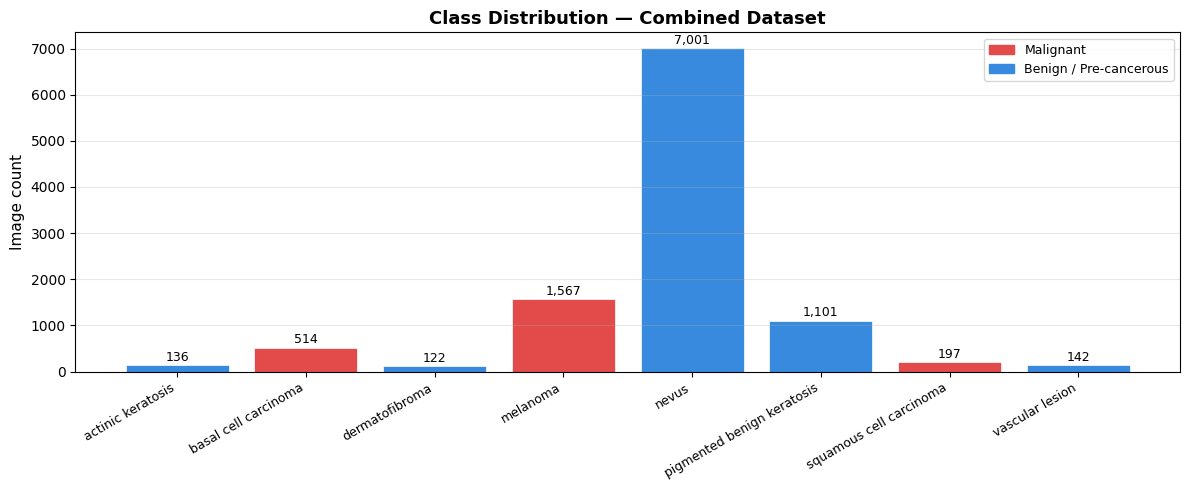

12:12:31  INFO  Saved → c:\graduation project\results\figures\phase0_class_distribution.png


In [15]:
# ── 14. Class distribution bar chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#E24B4A' if c in MALIGNANT else '#378ADD' for c in class_counts['label_str']]
bars   = ax.bar(class_counts['label_str'], class_counts['count'],
                color=colors, edgecolor='white', linewidth=0.5)

for bar, cnt in zip(bars, class_counts['count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'{cnt:,}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Image count', fontsize=11)
ax.set_title('Class Distribution — Combined Dataset', fontsize=13, fontweight='bold')
ax.set_xticklabels(class_counts['label_str'], rotation=30, ha='right', fontsize=9)
ax.legend(handles=[
    mpatches.Patch(color='#E24B4A', label='Malignant'),
    mpatches.Patch(color='#378ADD', label='Benign / Pre-cancerous'),
], fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

out = FIGURES_DIR / 'phase0_class_distribution.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
log.info(f"Saved → {out}")

In [16]:
# ── 15. Save health report CSV ────────────────────────────────────────────────
health = class_counts.copy()
health['pct']             = (100 * health['count'] / total).round(2)
health['is_malignant']    = health['label_str'].isin(MALIGNANT)
health['imbalance_ratio'] = (max_count / health['count']).round(2)

health_out = METRICS_DIR / 'phase0_health_report.csv'
health.to_csv(health_out, index=False)
log.info(f"Saved → {health_out}")
print(health.to_string(index=False))

12:12:31  INFO  Saved → c:\graduation project\results\metrics\phase0_health_report.csv


 label_int                  label_str  count   pct  is_malignant  imbalance_ratio
         0          actinic keratosis    136  1.26         False            51.48
         1       basal cell carcinoma    514  4.77          True            13.62
         2             dermatofibroma    122  1.13         False            57.39
         3                   melanoma   1567 14.54          True             4.47
         4                      nevus   7001 64.94         False             1.00
         5 pigmented benign keratosis   1101 10.21         False             6.36
         6    squamous cell carcinoma    197  1.83          True            35.54
         7            vascular lesion    142  1.32         False            49.30


## Phase 0 Complete ✓

| Output | Path |
|--------|------|
| Unified metadata | `data/metadata.csv` |
| Health report CSV | `results/metrics/phase0_health_report.csv` |
| Distribution chart | `results/figures/phase0_class_distribution.png` |

**Constants exported for later phases:** `DEVICE`, `SEED`, `CLASSES`, `CLASS2INT`, `INT2CLASS`, `MALIGNANT`, `META_OUT`

---
**Next → Phase 1: EDA** — class distribution deep dive, 45-image sample grid, per-channel stats, quality flags